In [1]:
import json
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-10-30 11:30:50,644 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MAP Performance vs ARE consis (Fullslice)

In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis/transfer_gauss_a001-005_Forg_ARE_scores.json
Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


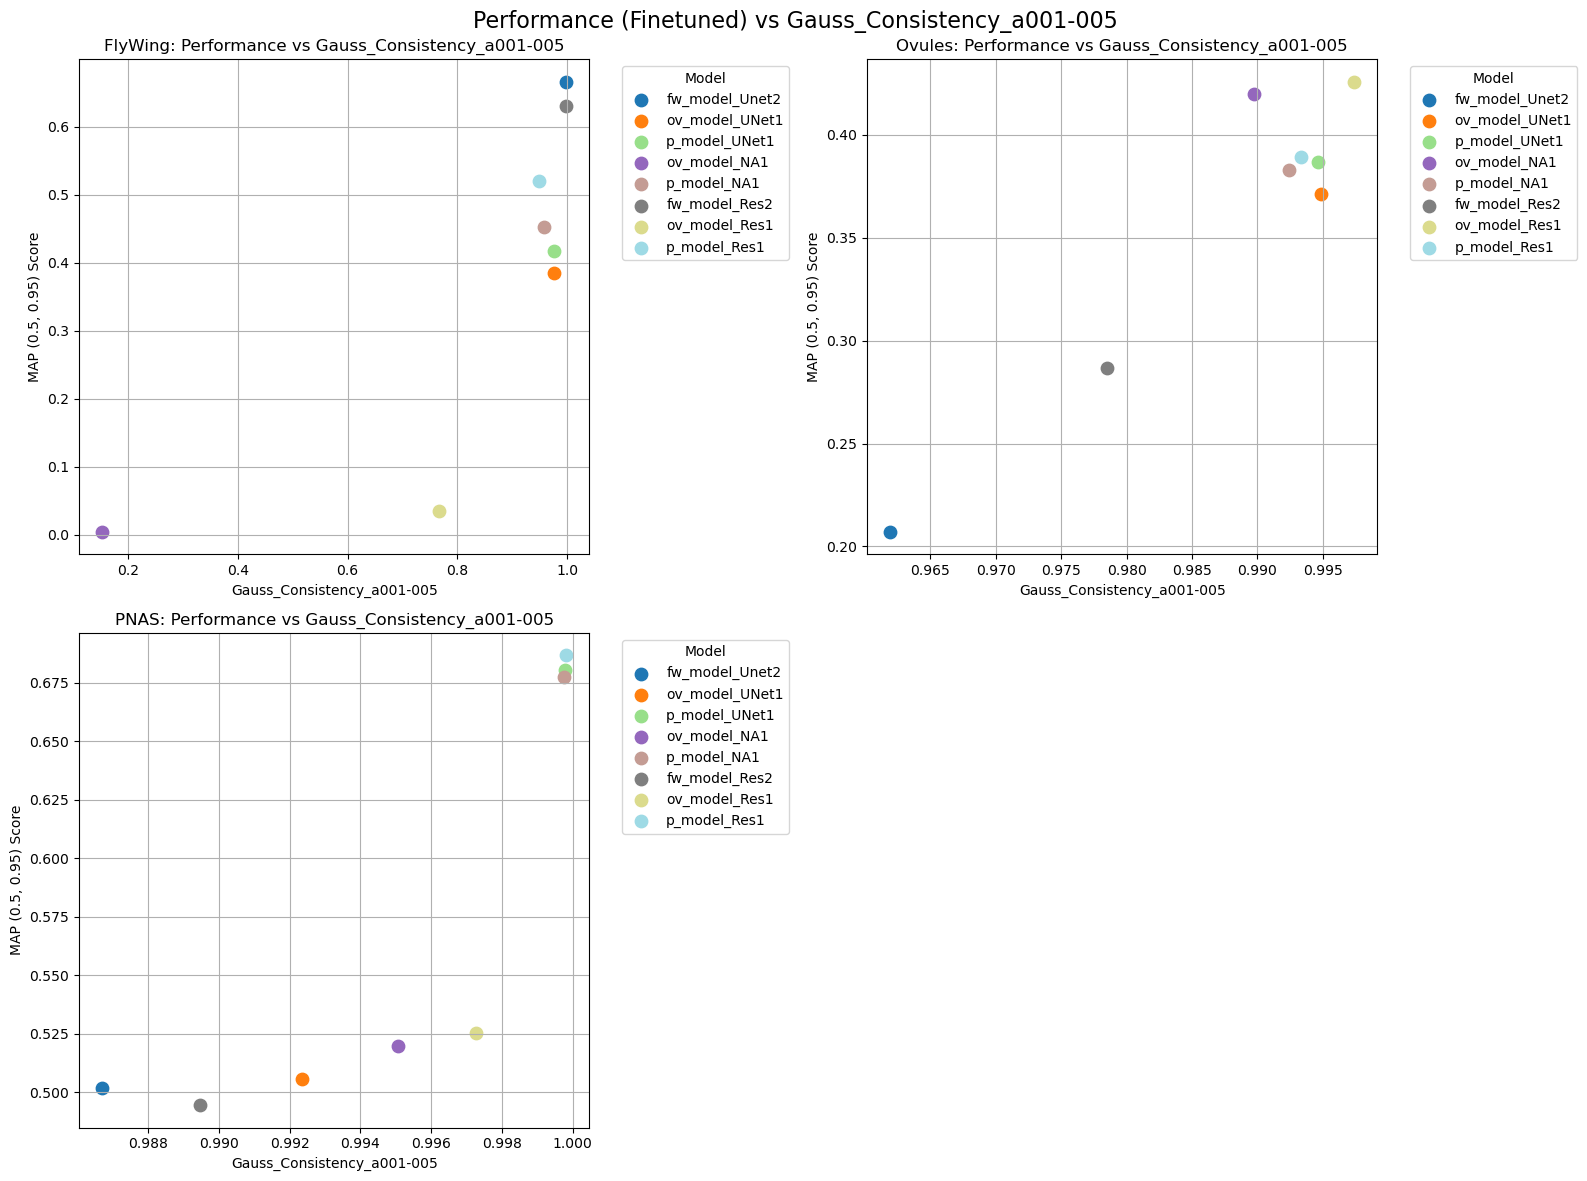

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.64     0.03   0.79        0.02  0.79     0.02
     Ovules   0.43     0.19   0.60        0.17  0.95     0.00
     PNAS     0.93     0.00   0.98        0.00  0.83     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis/transfer_gauss_a005-01_Forg_ARE_scores.json
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


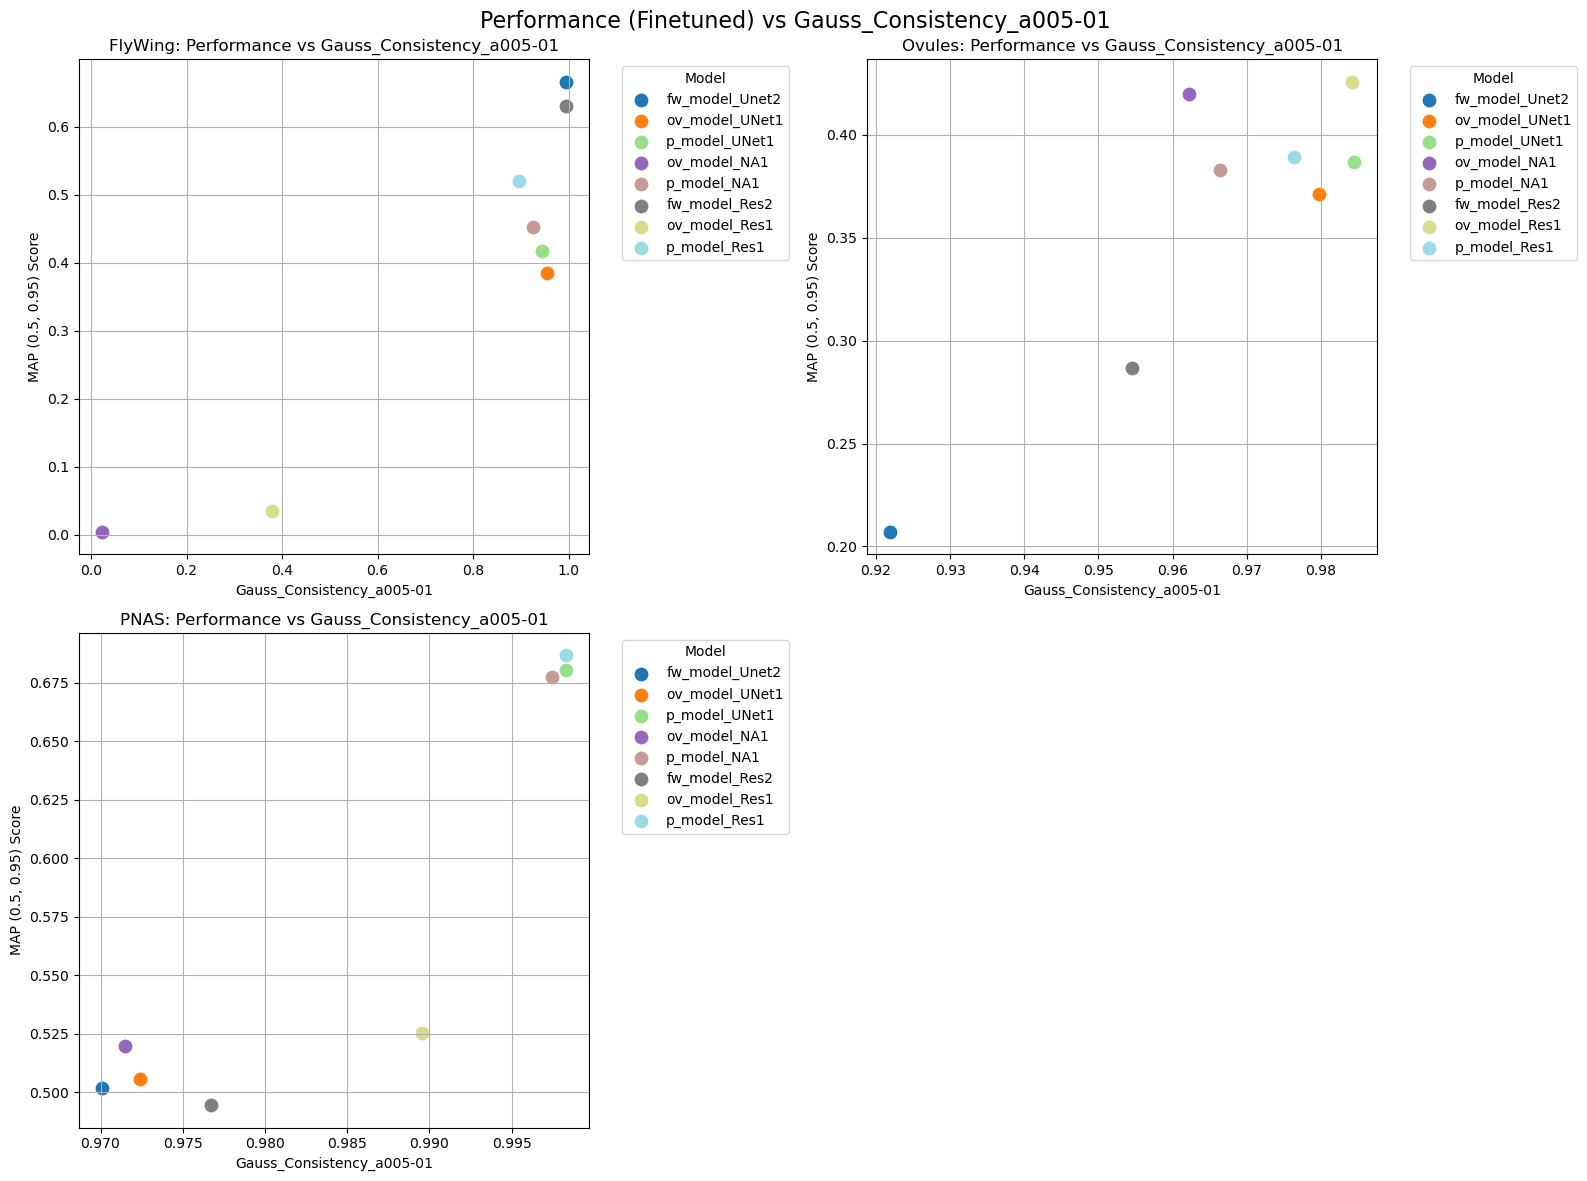

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.07   0.76        0.03  0.91      0.0
     Ovules   0.43     0.16   0.57        0.18  0.87      0.0
     PNAS     0.71     0.01   0.83        0.02  0.91      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis/transfer_gauss_a01-015_Forg_ARE_scores.json
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


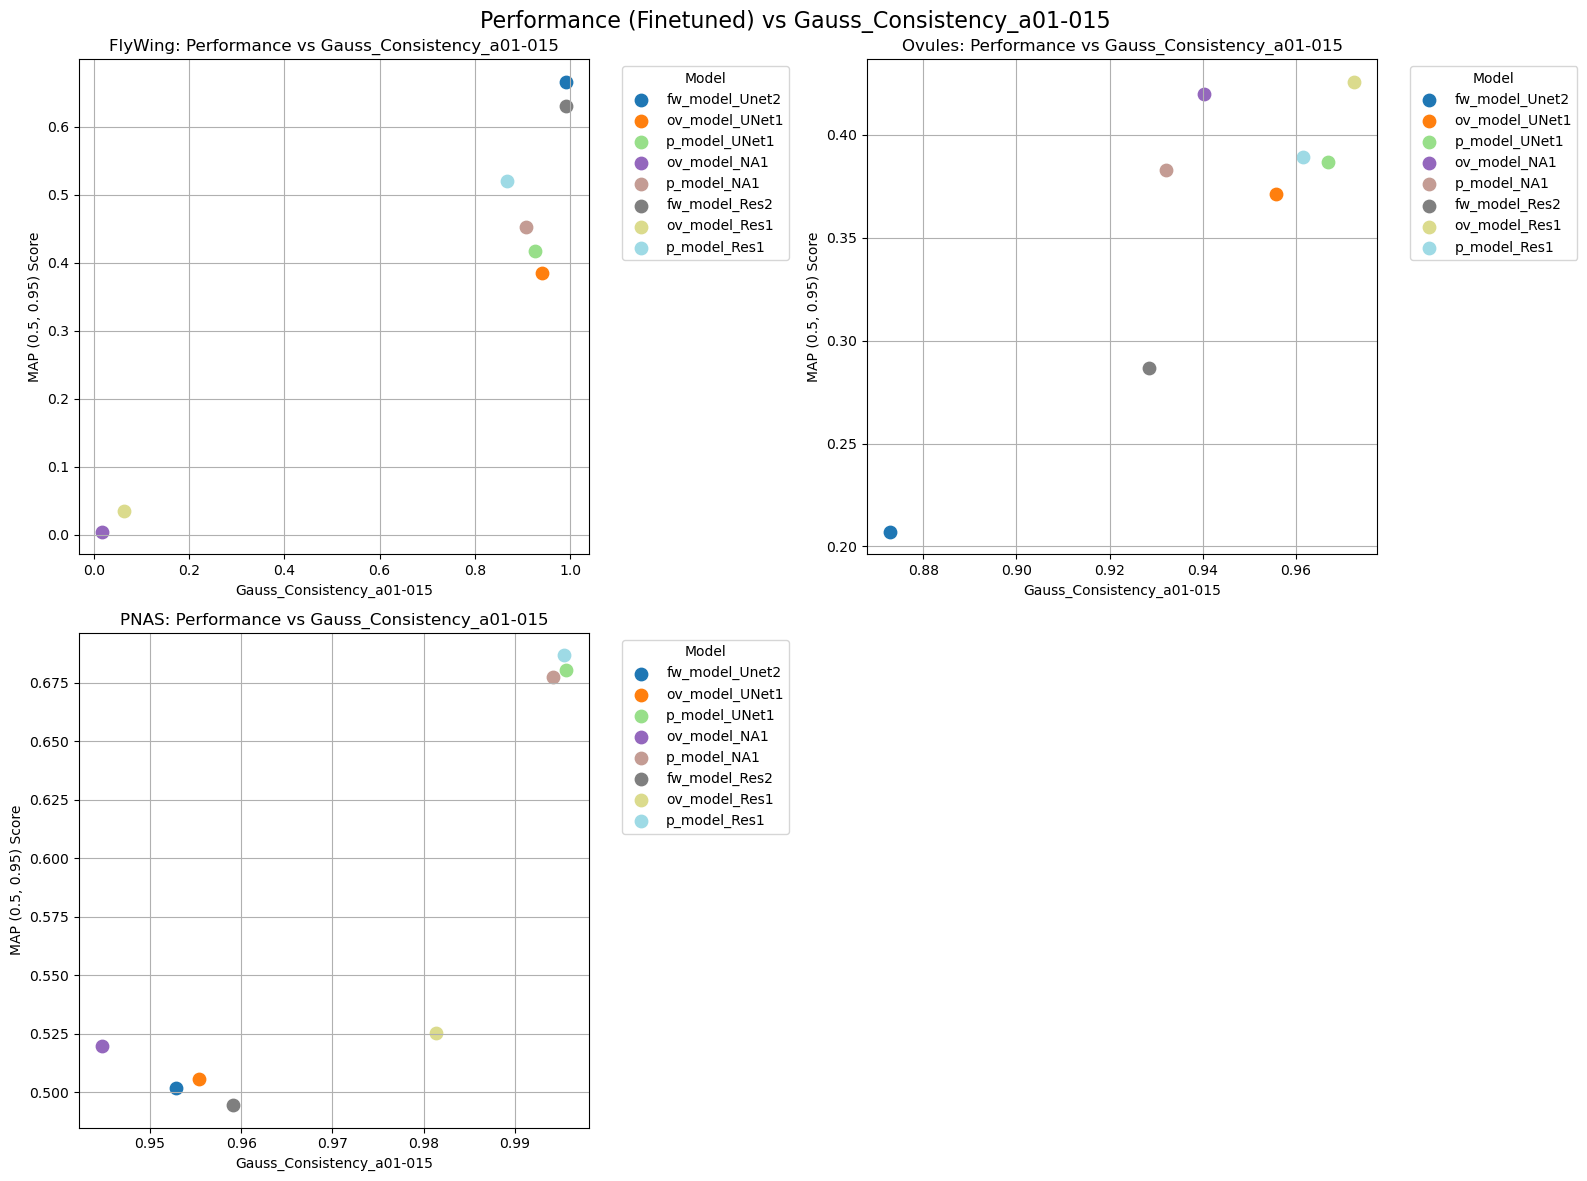

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.06   0.76        0.04  0.94      0.0
     Ovules   0.64     0.04   0.79        0.04  0.88      0.0
     PNAS     0.57     0.07   0.76        0.05  0.89      0.0
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis/transfer_gauss_a015-02_Forg_ARE_scores.json
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


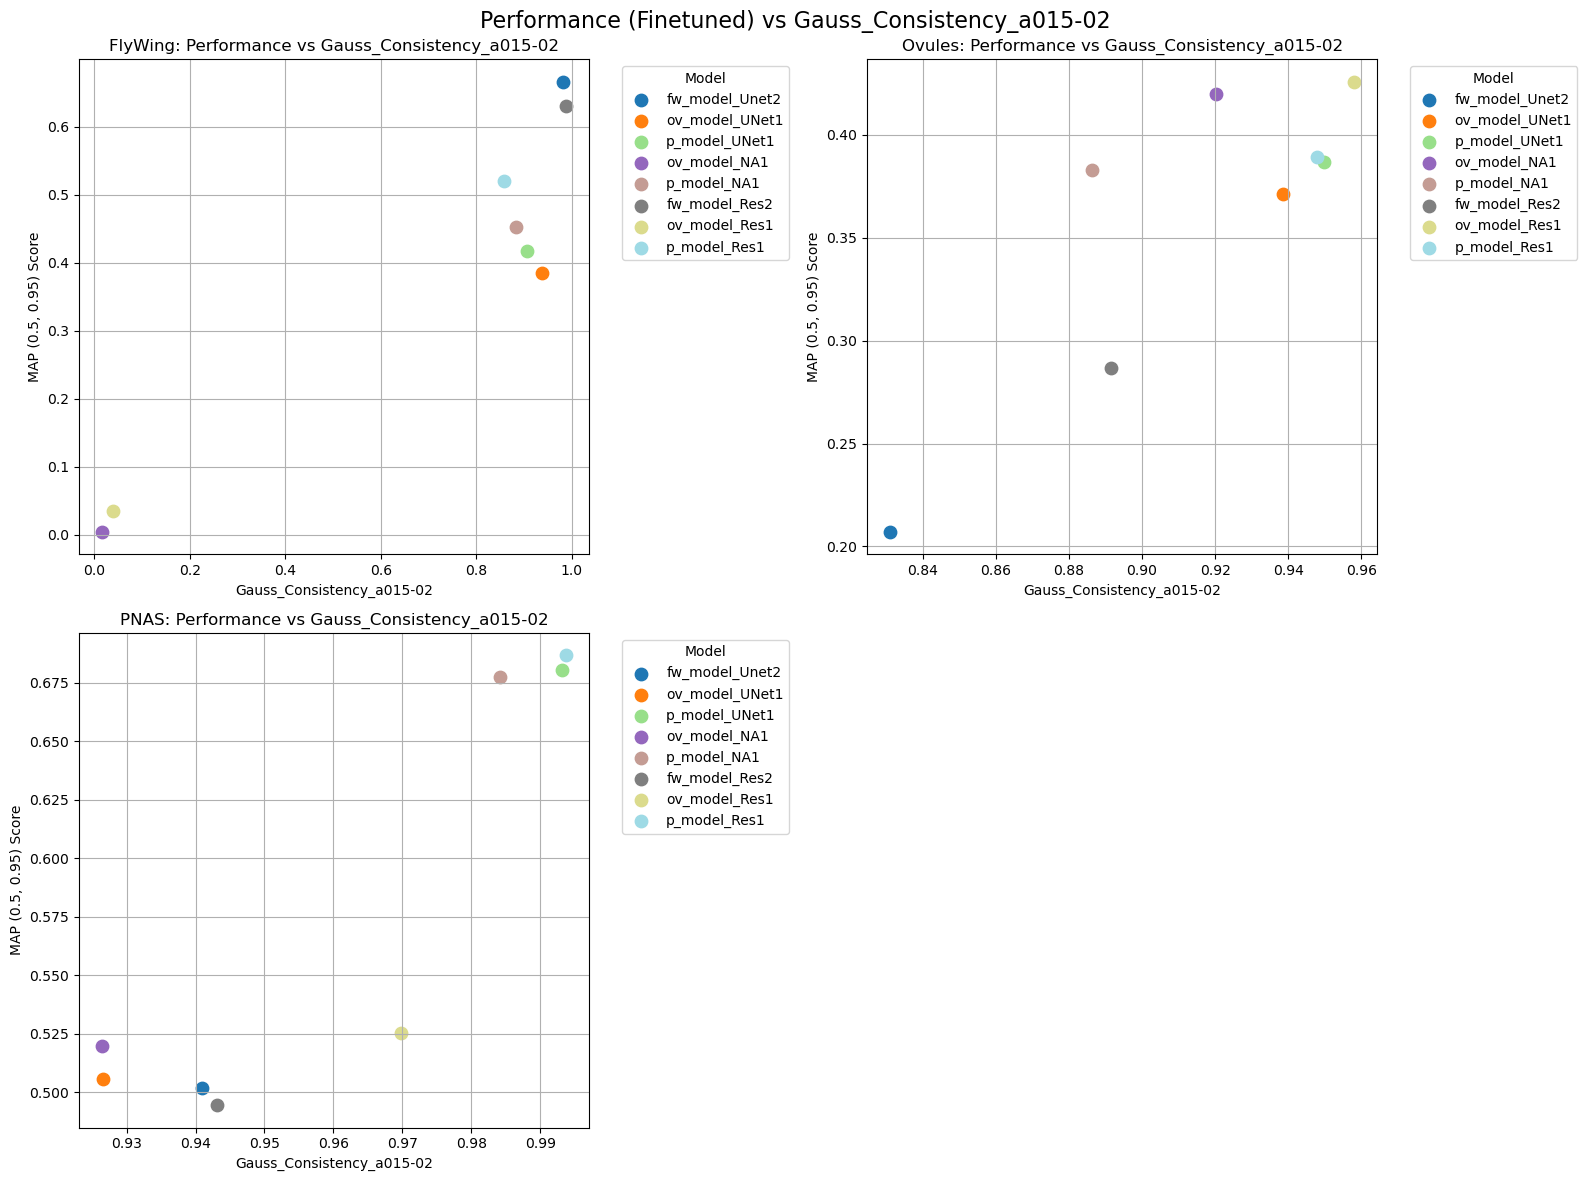

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.12   0.74        0.06  0.94     0.00
     Ovules   0.57     0.05   0.74        0.06  0.85     0.01
     PNAS     0.57     0.07   0.76        0.04  0.90     0.00
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis/transfer_gauss_a02-025_Forg_ARE_scores.json
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


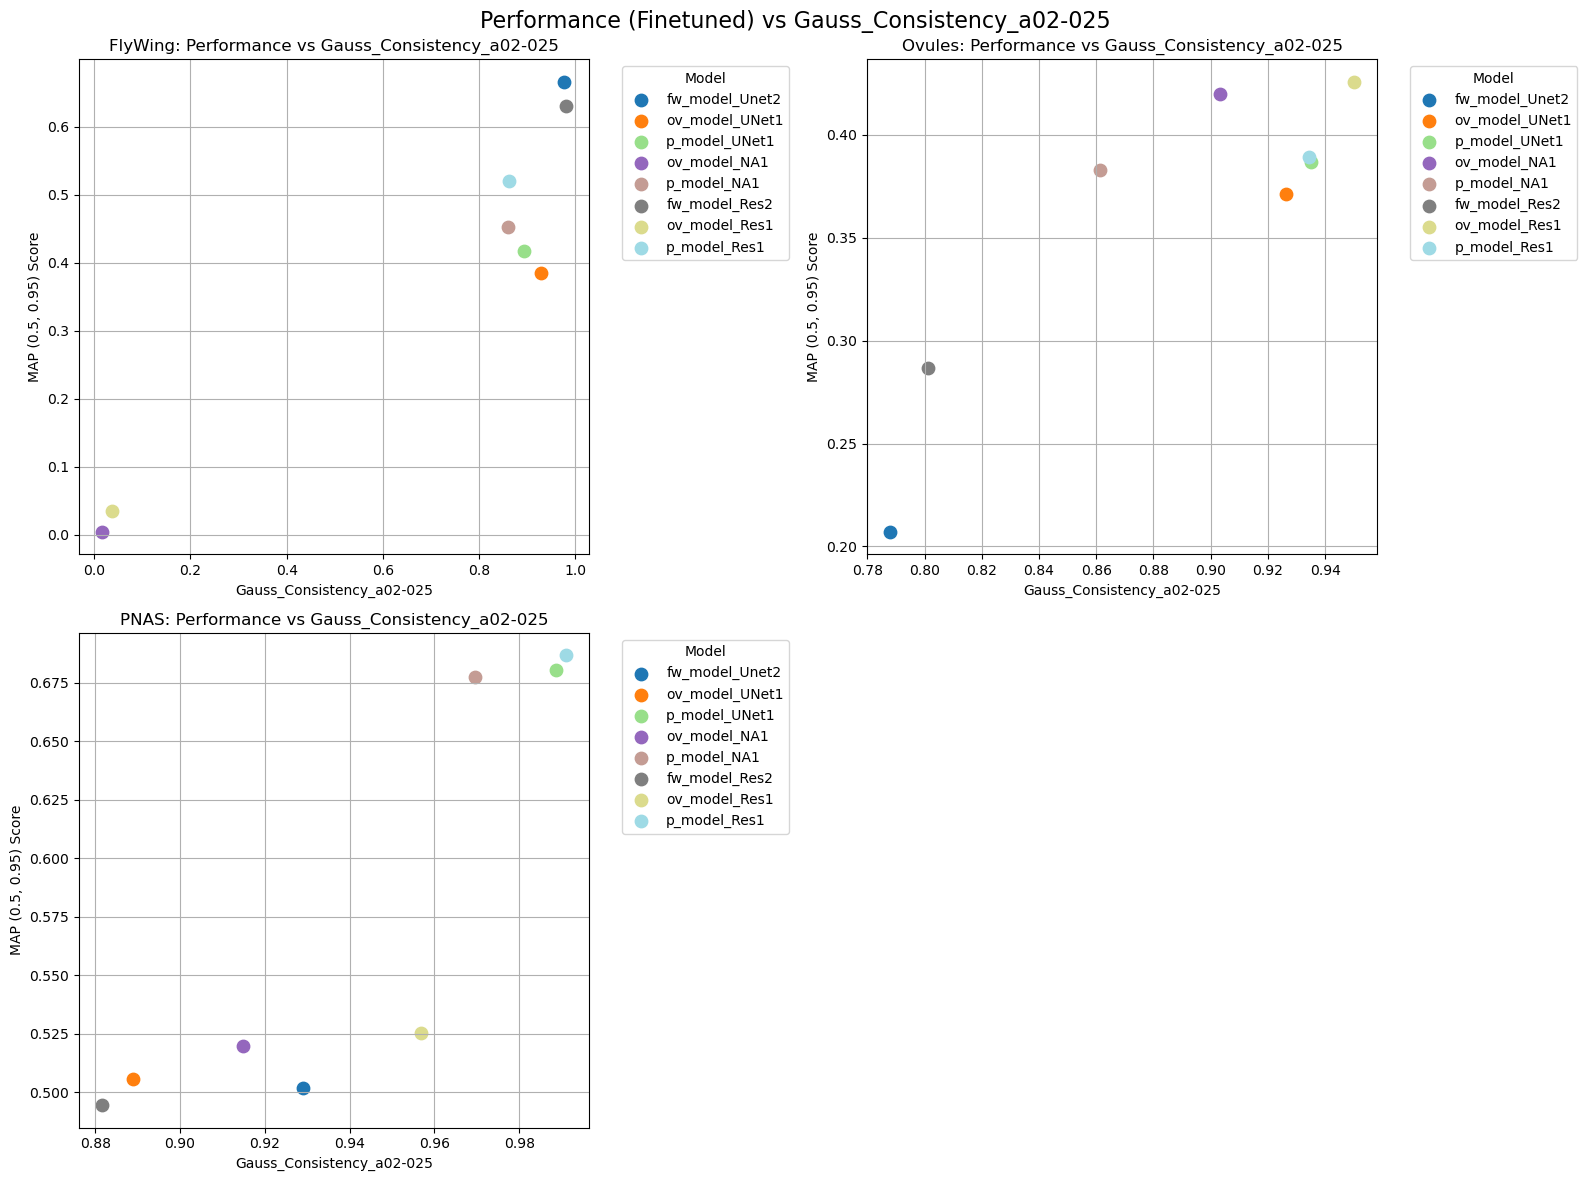

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.04   0.76        0.04  0.94      0.0
     Ovules   0.64     0.03   0.79        0.01  0.88      0.0
     PNAS     0.86     0.00   0.93        0.00  0.87      0.0


In [3]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/ARE_consis"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

for aug in selected_augmentations:
    file_name = f"transfer_gauss_{aug}_Forg_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
            invert_transfer_metric=True,
            finetuned=True,
            performance_metric_key="MAP (0.5, 0.95)",
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# # MAP Performance vs ARE consis (Weighted Average)

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_gauss_a001-005_ForgWA_ARE_scores.json
Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


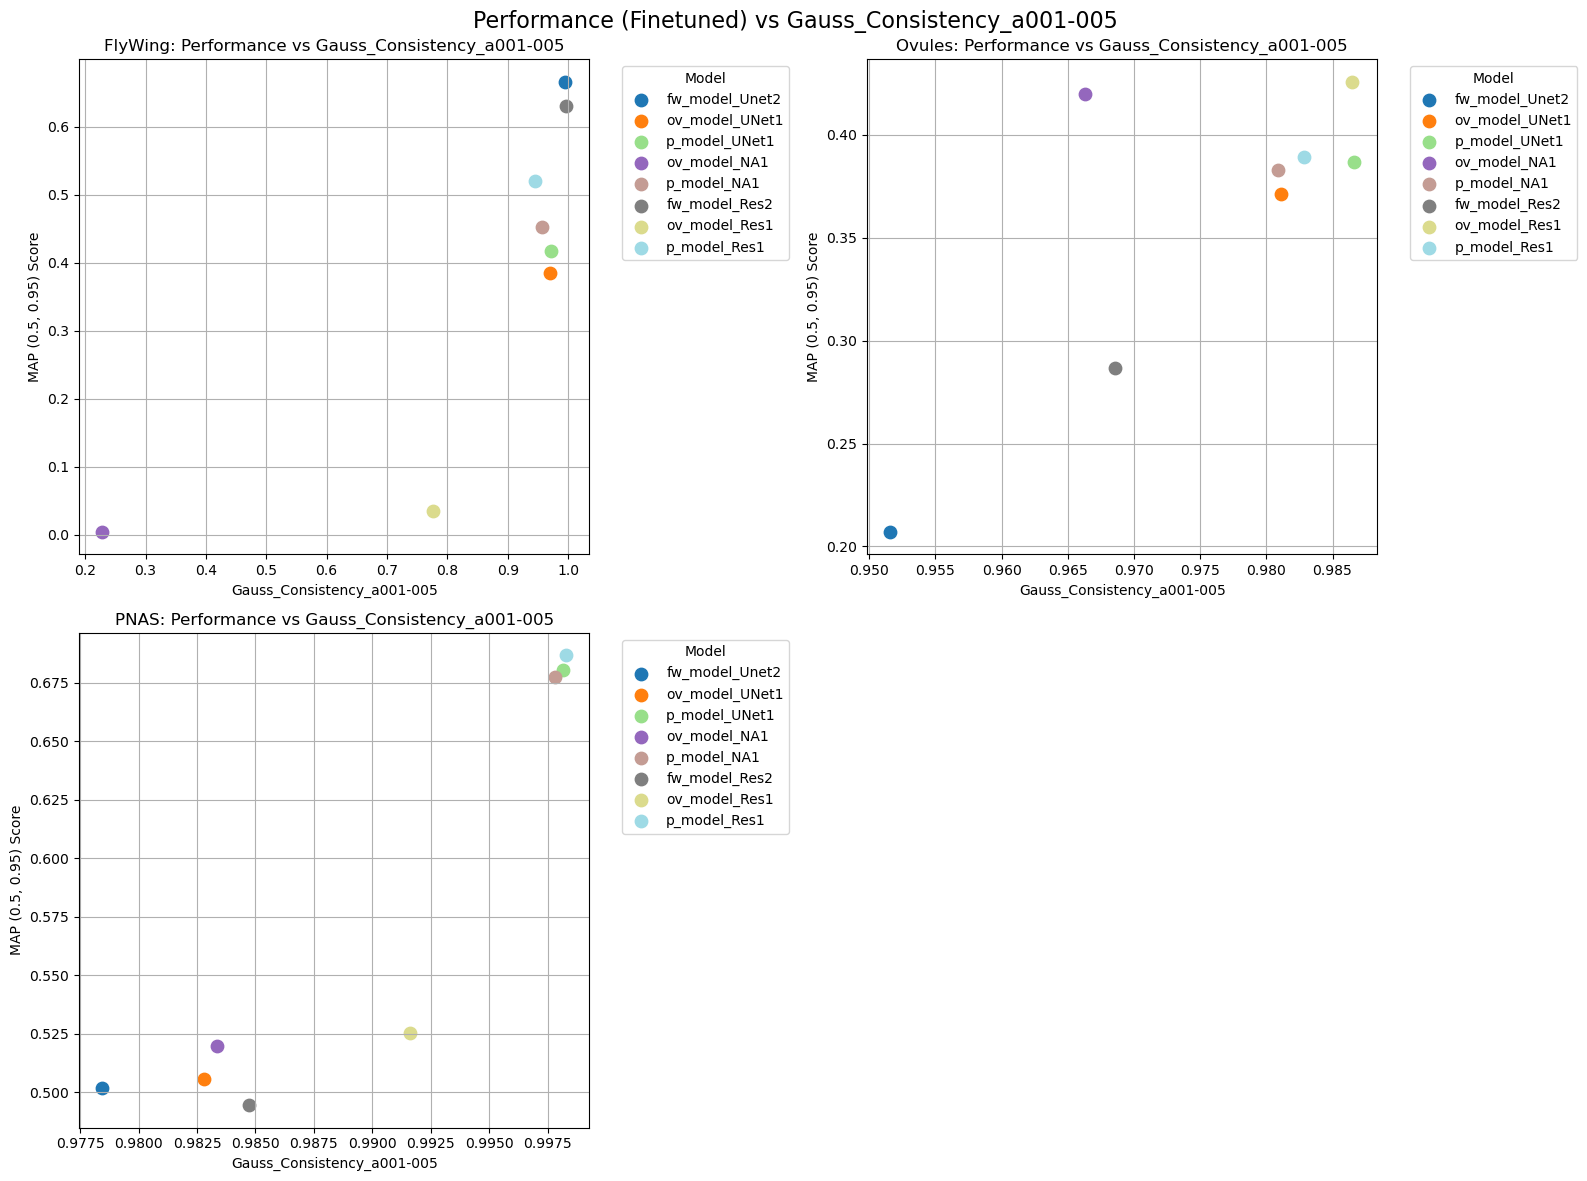

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.06   0.76        0.06  0.80     0.02
     Ovules   0.43     0.16   0.52        0.21  0.78     0.02
     PNAS     0.79     0.01   0.86        0.01  0.92     0.00
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_gauss_a005-01_ForgWA_ARE_scores.json
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


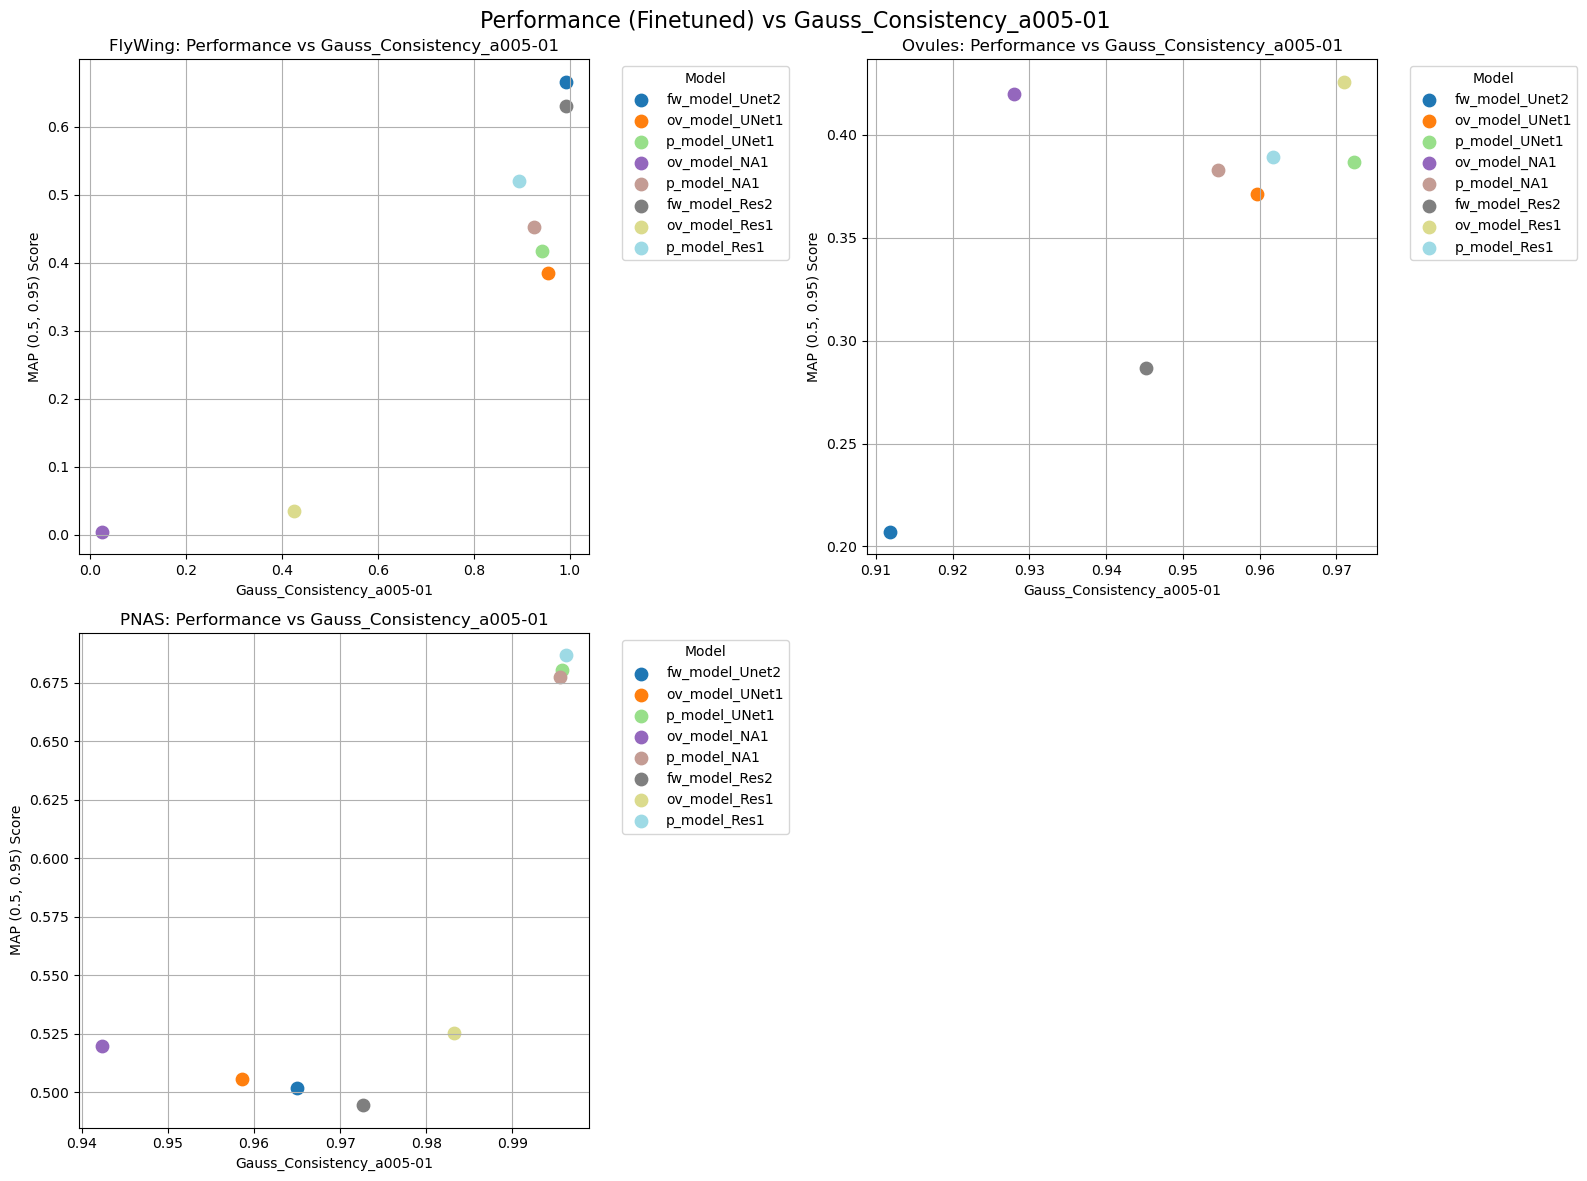

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.12   0.74        0.06  0.90     0.00
     Ovules   0.43     0.20   0.52        0.16  0.67     0.07
     PNAS     0.57     0.05   0.76        0.03  0.81     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_gauss_a01-015_ForgWA_ARE_scores.json
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


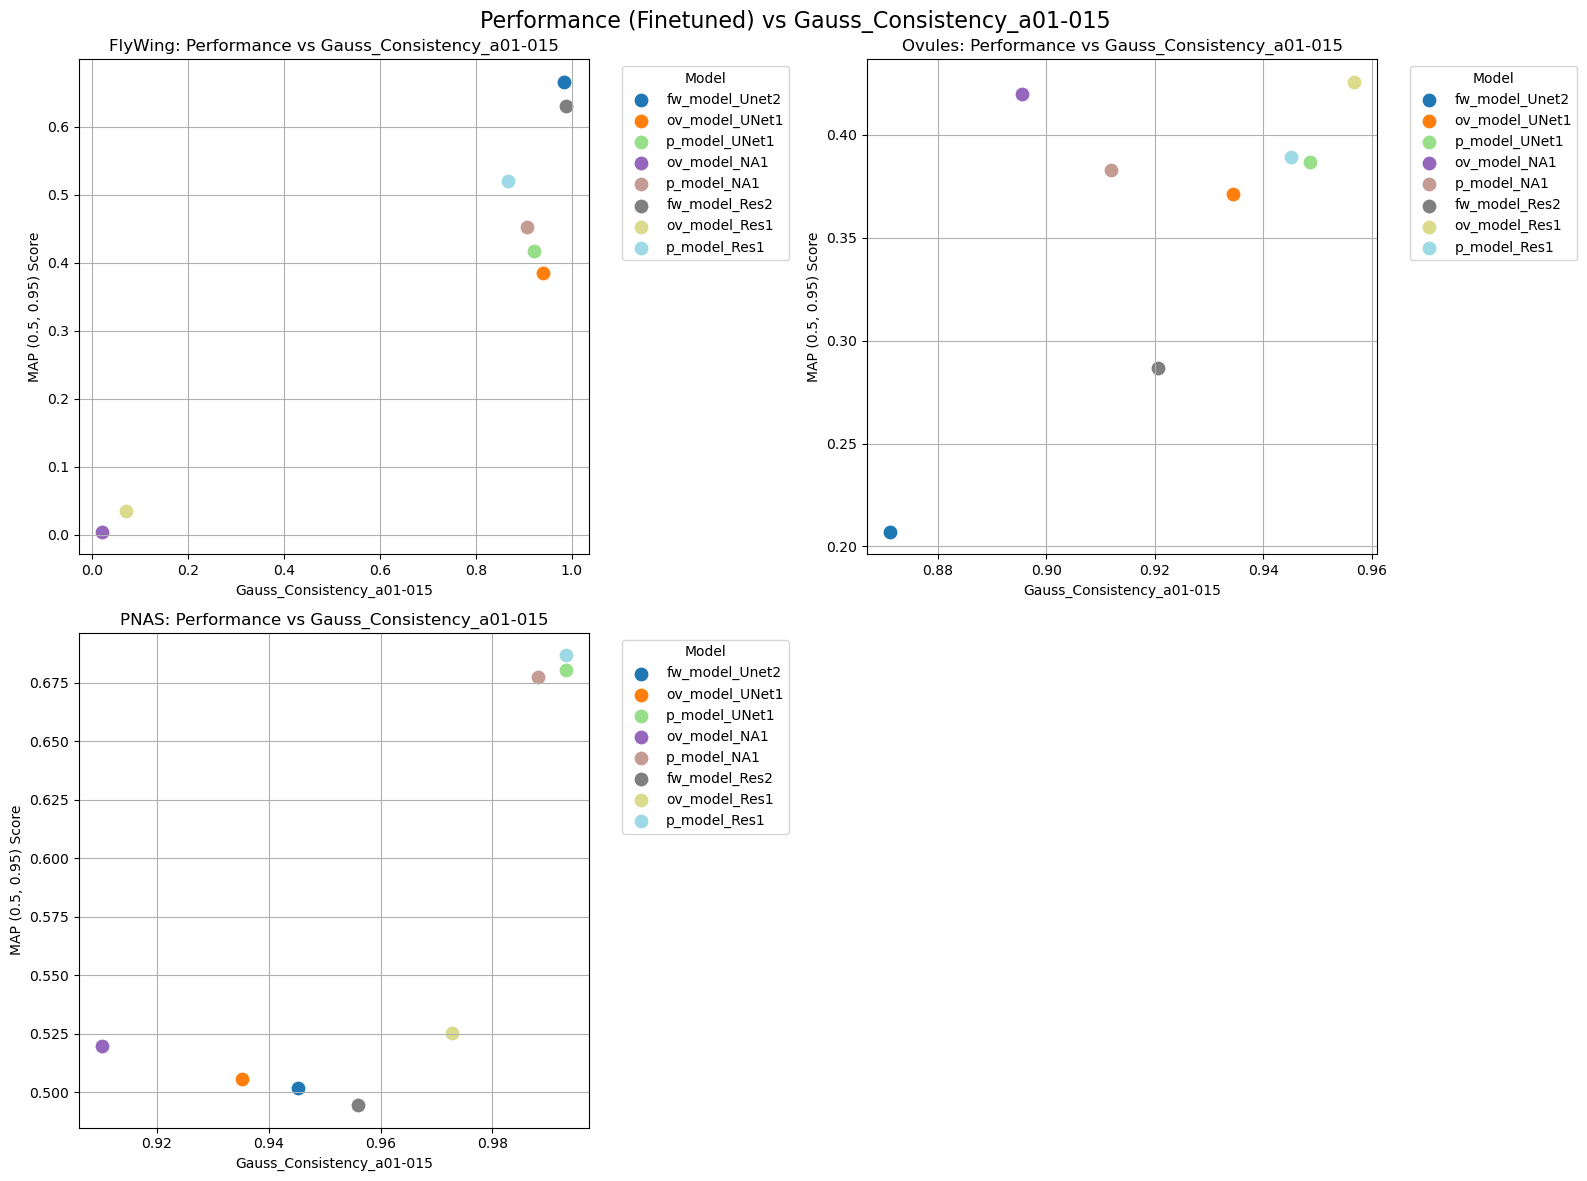

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.11   0.74        0.06  0.94     0.00
     Ovules   0.43     0.17   0.55        0.16  0.65     0.08
     PNAS     0.50     0.12   0.74        0.06  0.81     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_gauss_a015-02_ForgWA_ARE_scores.json
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


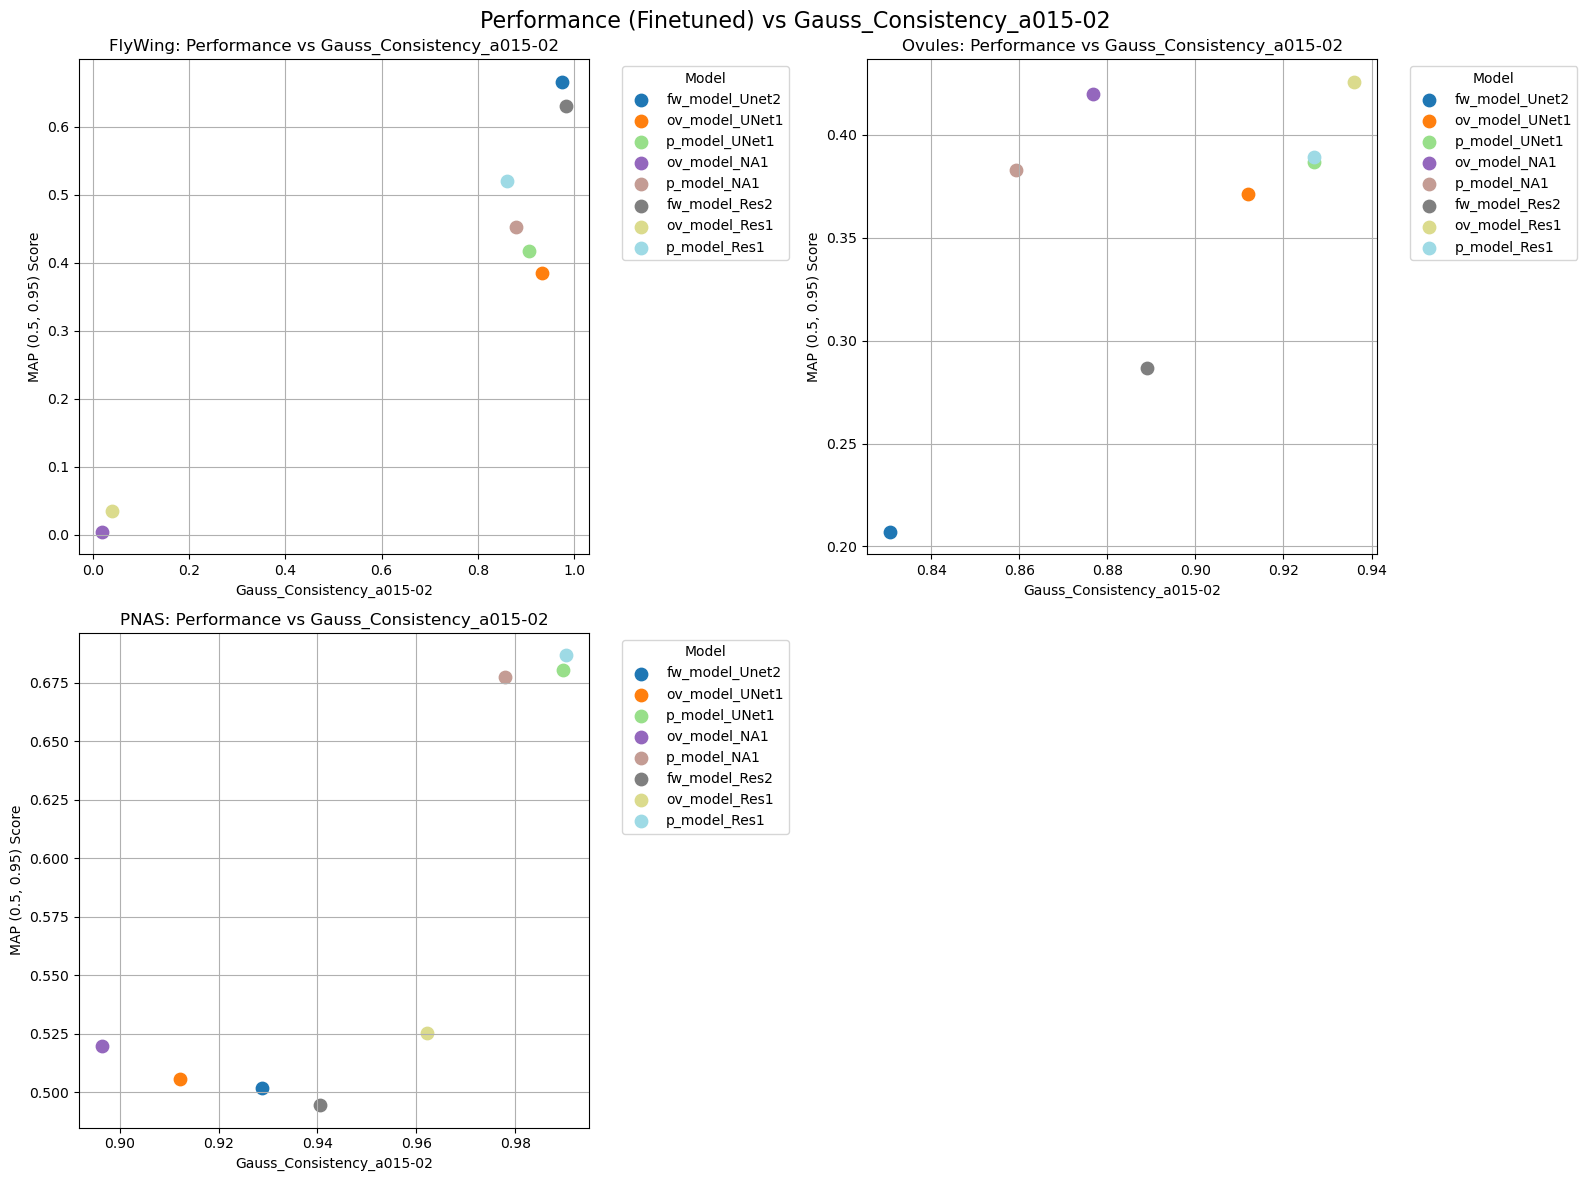

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.09   0.74        0.04  0.94     0.00
     Ovules   0.50     0.12   0.62        0.14  0.67     0.07
     PNAS     0.57     0.08   0.76        0.04  0.84     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_gauss_a02-025_ForgWA_ARE_scores.json
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


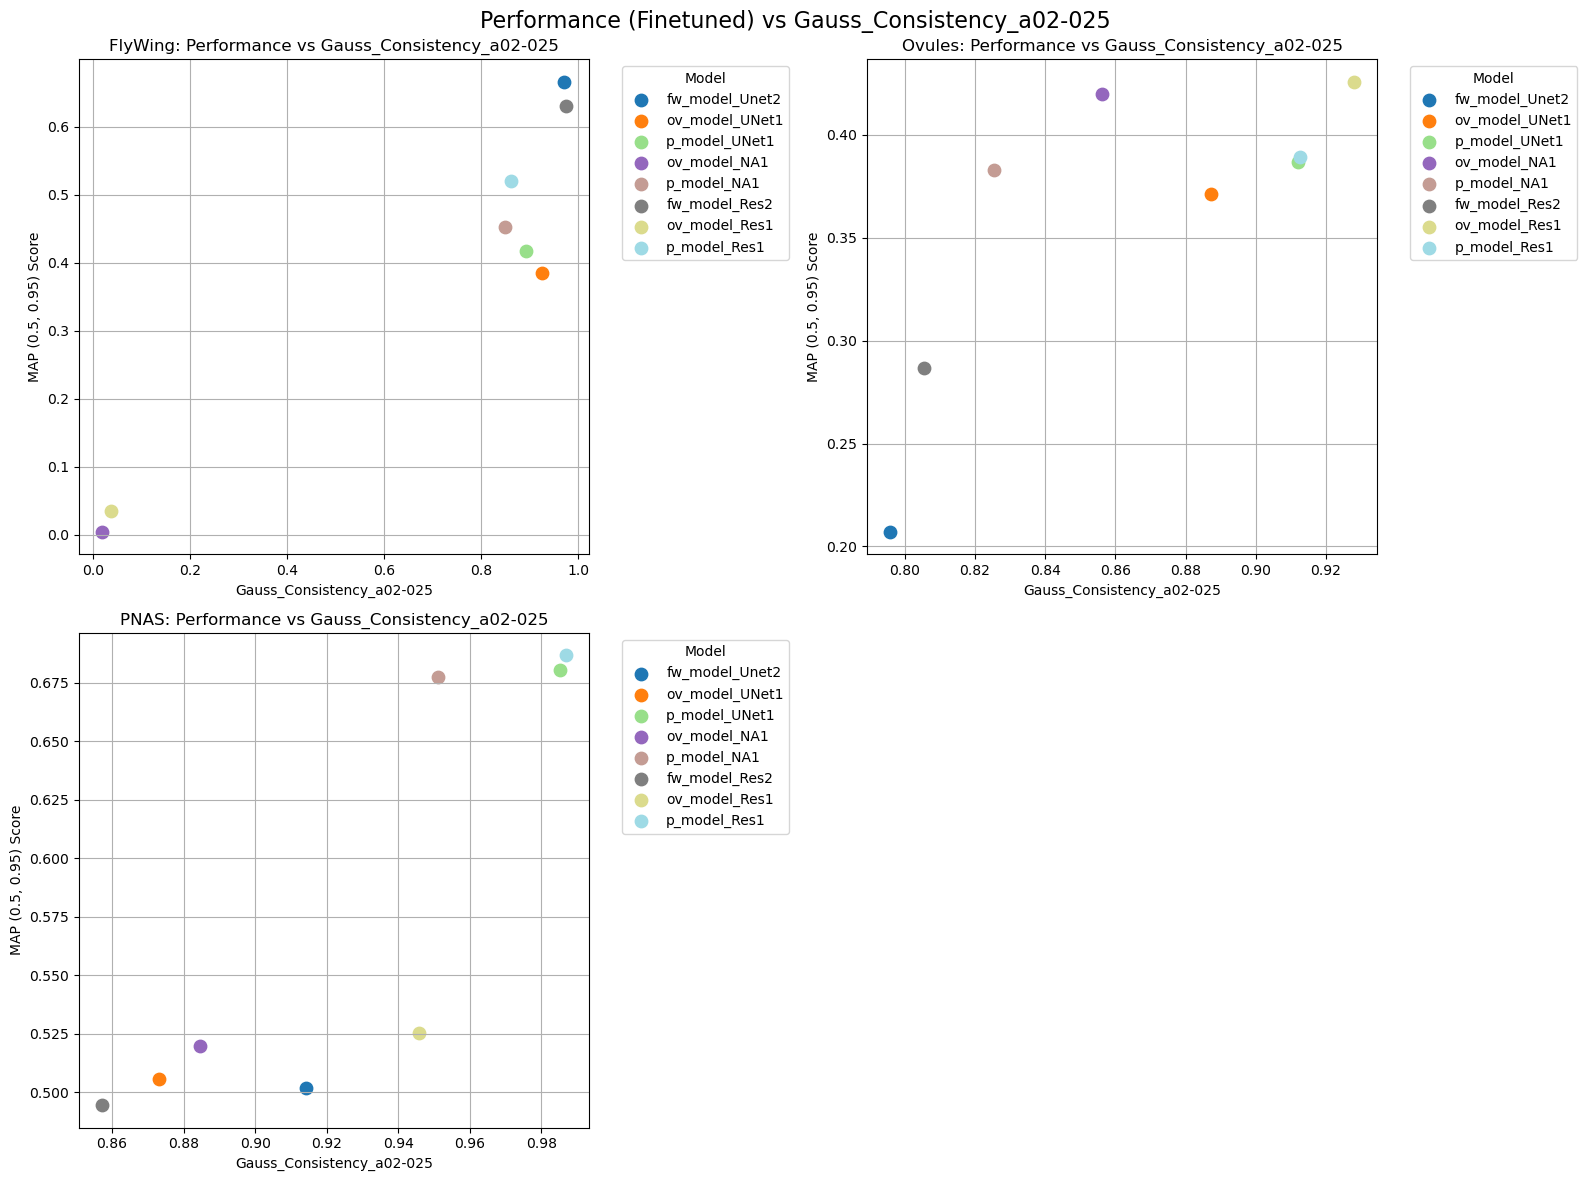

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.07   0.76        0.04  0.94     0.00
     Ovules   0.71     0.01   0.81        0.02  0.76     0.03
     PNAS     0.86     0.00   0.93        0.00  0.86     0.01


In [4]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

for aug in selected_augmentations:
    file_name = f"transfer_gauss_{aug}_ForgWA_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_Consistency_{aug}",
        invert_transfer_metric=True,
        finetuned=True,
        performance_metric_key="MAP (0.5, 0.95)",
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# ARE Performance vs ARE consis (Fullslice)

In [5]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_No_Ignore/transfer_performance_ARE_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_Gauss_a001-a005_Forg_ARE_scores.json
Processing: Gauss_Consistency_a001-a005
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


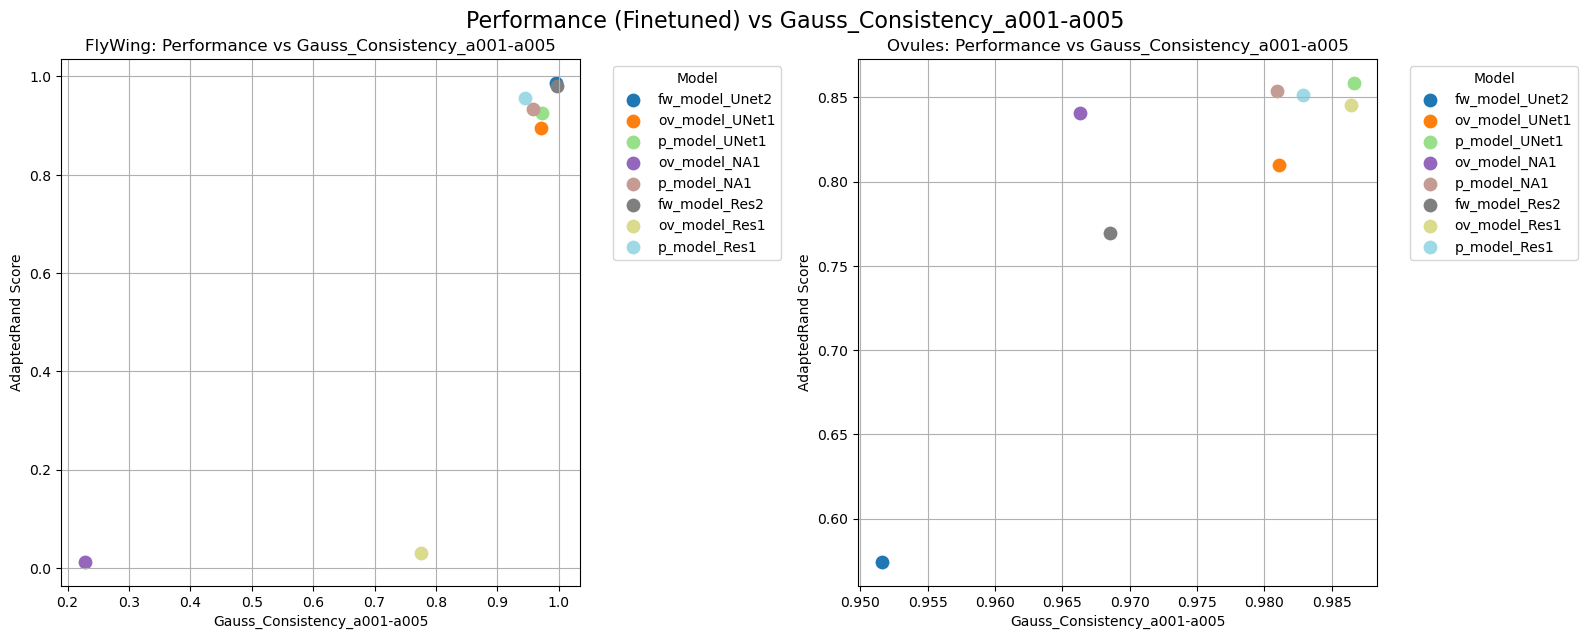

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.08   0.76        0.05  0.83     0.01
     Ovules   0.57     0.07   0.74        0.05  0.86     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_Gauss_a005-a01_Forg_ARE_scores.json
Processing: Gauss_Consistency_a005-a01
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


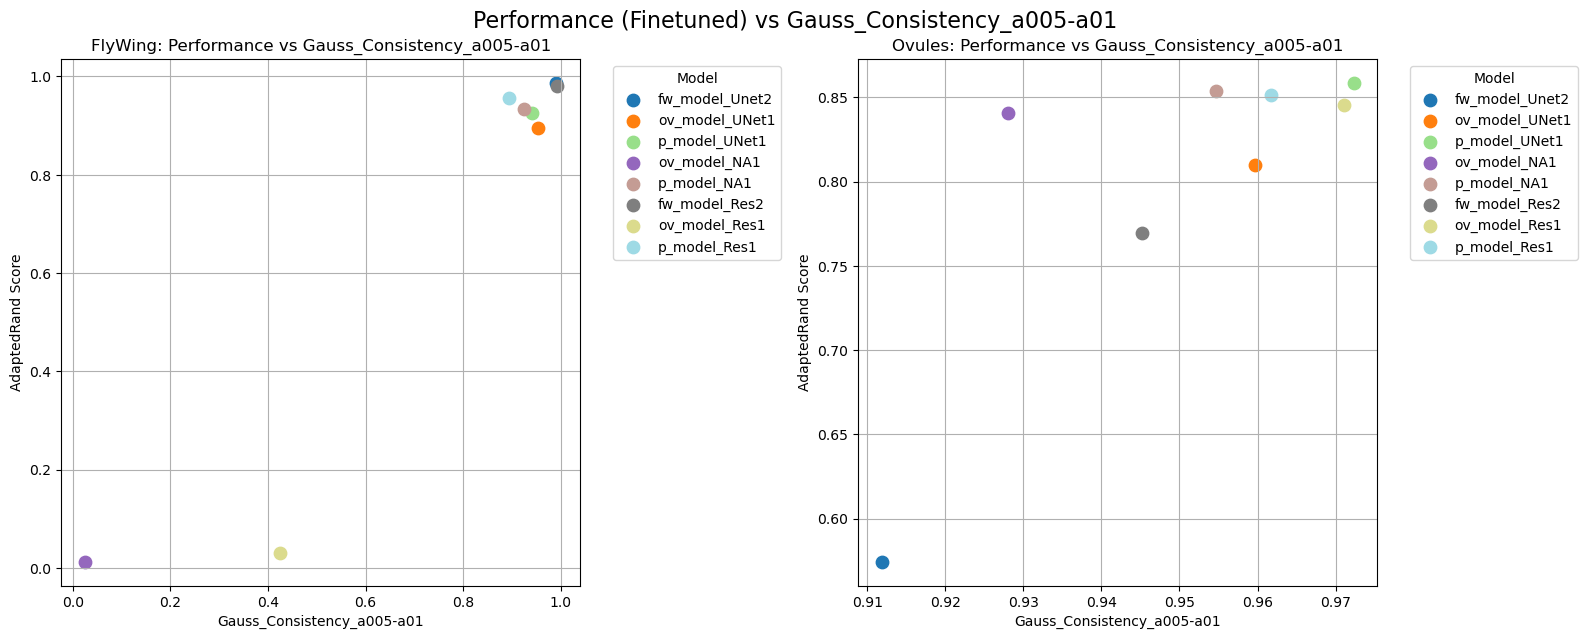

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.11   0.74        0.04  0.95     0.00
     Ovules   0.57     0.06   0.74        0.05  0.78     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_Gauss_a01-a015_Forg_ARE_scores.json
Processing: Gauss_Consistency_a01-a015
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


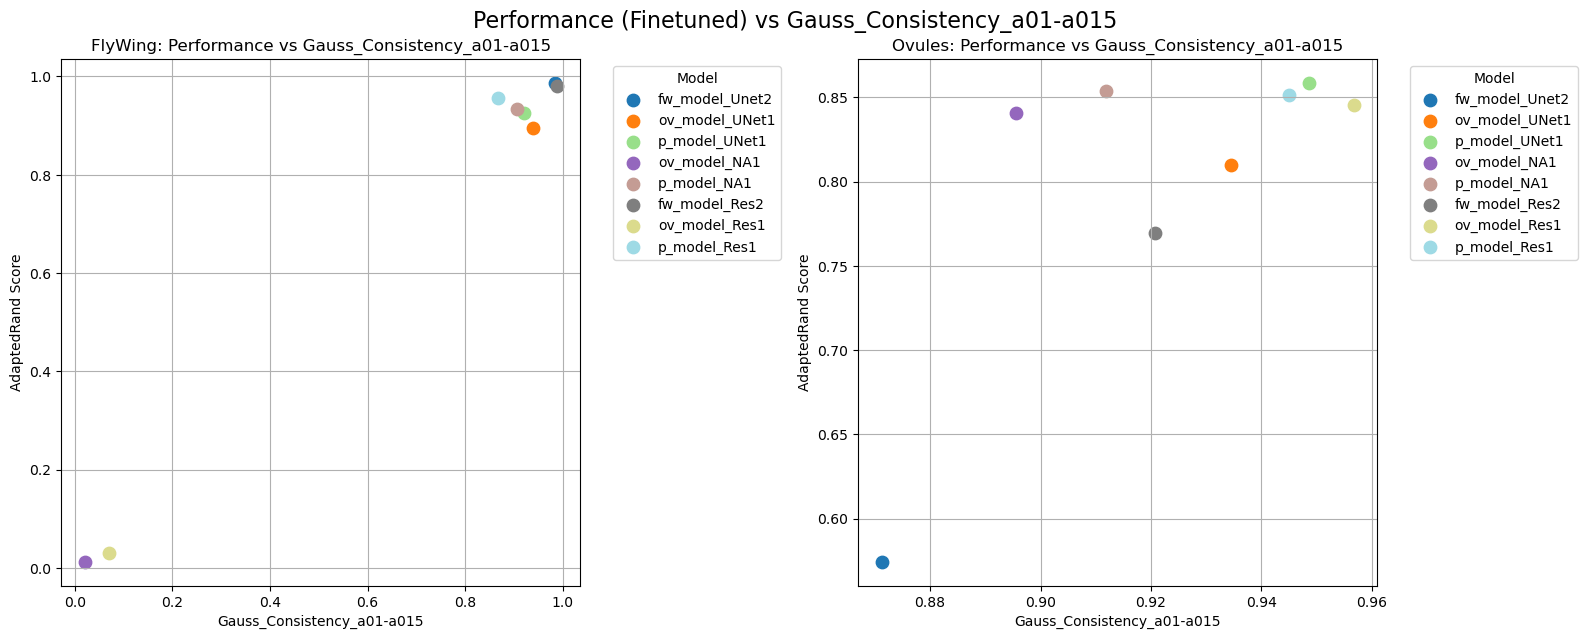

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.50     0.09   0.74        0.05  1.00     0.00
     Ovules   0.43     0.16   0.55        0.21  0.73     0.04
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_Gauss_a015-a02_Forg_ARE_scores.json
Processing: Gauss_Consistency_a015-a02
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


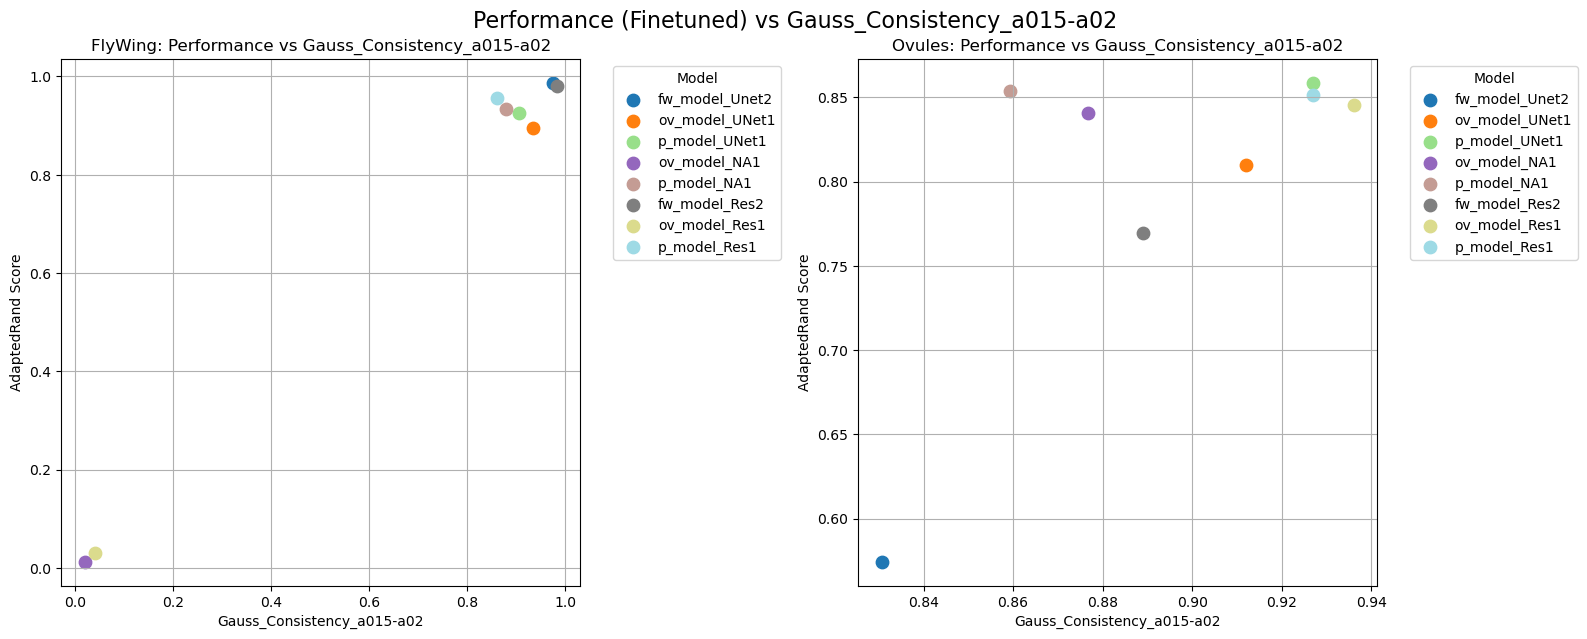

                kt  kt pval  s rho  s rho pval   pr  pr pval
Task targets                                                
Mito FlyWing  0.50     0.10   0.74        0.03  1.0     0.00
     Ovules   0.36     0.28   0.48        0.27  0.7     0.05
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis/transfer_Gauss_a02-a025_Forg_ARE_scores.json
Processing: Gauss_Consistency_a02-a025
Number of targets: 2
  Target 1: FlyWing
  Target 2: Ovules


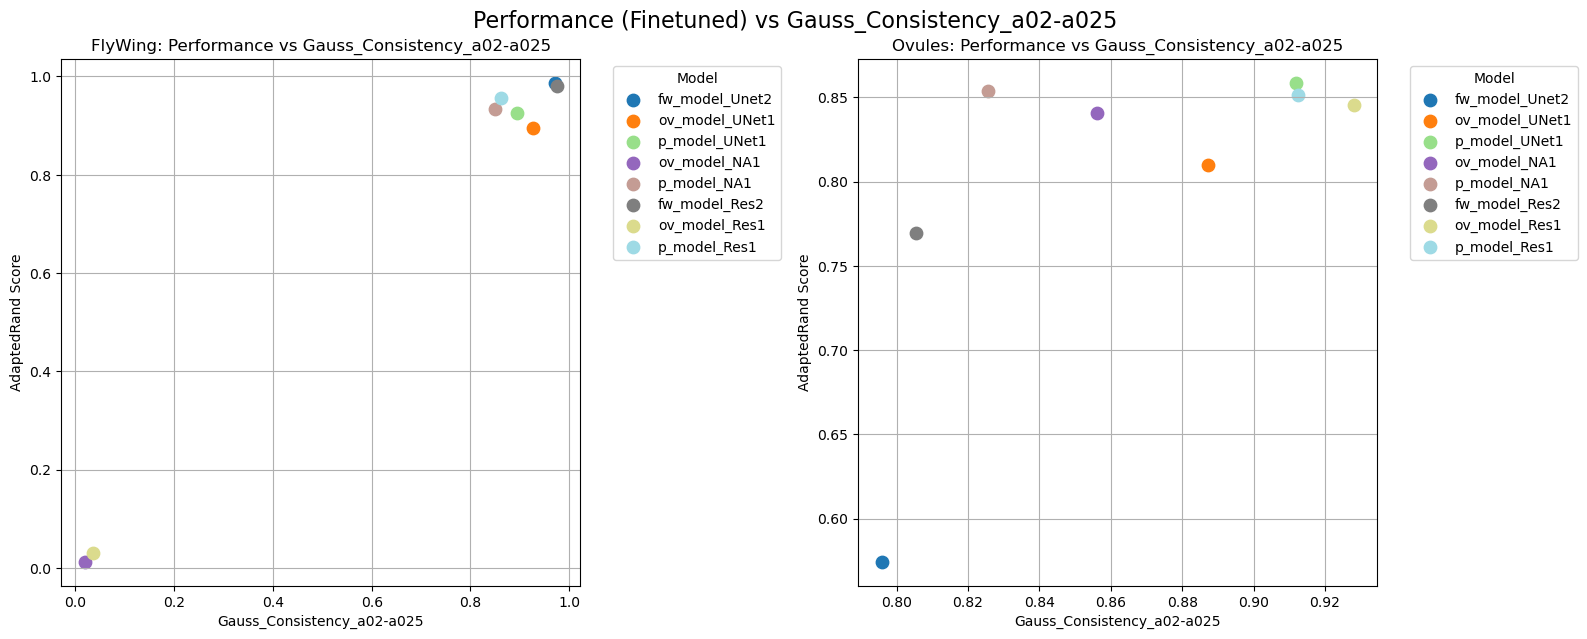

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.57     0.06   0.76        0.04  1.00     0.00
     Ovules   0.43     0.18   0.60        0.13  0.66     0.07


In [8]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/fullslice_weighted_avg_No_Ignore/ARE_consis"
selected_augmentations = ["a001-a005", "a005-a01", "a01-a015", "a015-a02", "a02-a025"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}_Forg_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"Gauss_Consistency_{aug}",
        invert_transfer_metric=True,
        invert_perf_metric=True,
        finetuned=True,
        performance_metric_key="AdaptedRand",
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
        invert_perf_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        